## 1. Imports and Configuration

In [2]:
# [IMPORTS]
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import warnings
warnings.filterwarnings('ignore')

from scipy import stats
from sklearn.linear_model import LassoCV, LogisticRegressionCV
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold
from sklearn.metrics import r2_score, roc_auc_score
import os

In [3]:
# [CONFIG]
TRAIN_FILE    = '../../data/processed/clinical_merged/train_beta_5e5.csv'
VAL_FILE      = '../../data/processed/clinical_merged/val_beta_5e5.csv'
KL_FILE       = '../../data/baseline/kl_divergence_beta_5.00e-05.csv'
OUTPUT_DIR    = '../../results/lasso/'
FIGURES_DIR   = '../../results/figures/'
os.makedirs(OUTPUT_DIR,  exist_ok=True)
os.makedirs(FIGURES_DIR, exist_ok=True)

PATIENT_COL  = 'PATNO'
LABEL_COL    = 'label'
RANDOM_STATE = 42
N_FOLDS      = 5

# Active dimensions from KL divergence
df_kl       = pd.read_csv(KL_FILE)
ACTIVE_DIMS = df_kl[df_kl['mean_kl'] > 0.05]['dimension'].tolist()

# Tasks to analyse
TASKS = {
    'age_hc':      {'target': 'AGE_AT_VISIT',     'type': 'regression',     'subset': 'HC'},
    'pd_hc':       {'target': 'label',             'type': 'classification', 'subset': 'PD_HC'},
    'bradyrig':    {'target': 'AI_BradyRig_Diff',  'type': 'regression',     'subset': 'PD'},
    'tremor':      {'target': 'AI_Tremor_Diff',    'type': 'regression',     'subset': 'PD'},
    'np3tot':      {'target': 'UPDRS3_TOTAL',      'type': 'regression',     'subset': 'PD'},
}

print(f"Active dimensions: {len(ACTIVE_DIMS)}")
print(f"Tasks: {list(TASKS.keys())}")


Active dimensions: 50
Tasks: ['age_hc', 'pd_hc', 'bradyrig', 'tremor', 'np3tot']


## 2. Load Data

In [30]:
# [LOAD-DATA]

df_train = pd.read_csv(TRAIN_FILE)
df_val   = pd.read_csv(VAL_FILE)


# Convert Sex to binary
df_train['SEX'] = df_train['Sex'].map({'F': 0, 'M': 1})
df_val['SEX']   = df_val['Sex'].map({'F': 0, 'M': 1})

# Create subsets for each tasks:- HC subset — used for Task A (age in HC)
                               #- PD subset — used for Tasks C, D, E (BradyRig_Diff, Tremor_Diff, NP3TOT)
                               #- PD_HC subset — used for Task B (PD vs HC separation)
subsets_train = {
    'HC':    df_train[df_train[LABEL_COL] == 'Control'].copy(),
    'PD':    df_train[df_train[LABEL_COL] == 'PD'].copy(),
    'PD_HC': df_train[df_train[LABEL_COL].isin(['PD', 'Control'])].copy()
}

subsets_val = {
    'HC':    df_val[df_val[LABEL_COL] == 'Control'].copy(),
    'PD':    df_val[df_val[LABEL_COL] == 'PD'].copy(),
    'PD_HC': df_val[df_val[LABEL_COL].isin(['PD', 'Control'])].copy()
}

# Add binary label for classification
for d in [subsets_train, subsets_val]:
    for k in d:
        d[k]['label_binary'] = (d[k][LABEL_COL] == 'PD').astype(int)

print("=== Dataset ===")
for k, v in subsets_train.items():
    print(f"  Train {k}: {len(v)} rows, {v[PATIENT_COL].nunique()} patients")
print()
for k, v in subsets_val.items():
    print(f"  Val {k}:   {len(v)} rows, {v[PATIENT_COL].nunique()} patients")

print(f"\nActive dims available: {all(d in df_train.columns for d in ACTIVE_DIMS)}")


=== Dataset ===
  Train HC: 313 rows, 308 patients
  Train PD: 2666 rows, 1310 patients
  Train PD_HC: 2979 rows, 1618 patients

  Val HC:   65 rows, 64 patients
  Val PD:   688 rows, 337 patients
  Val PD_HC:   753 rows, 401 patients

Active dims available: True


## 3. LASSO CV
What it does: For each task, runs Lasso with cross-validation to find the optimal regularisation strength, then identifies which dimensions are selected and how many are needed.

In [106]:
# [LASSO-CV]

def run_lasso_task(df_tr, df_vl, task_name, task_info):
    target    = 'label_binary' if task_info['type'] == 'classification' else task_info['target']
    is_clf    = task_info['type'] == 'classification'
    feat_cols = ACTIVE_DIMS + (['SEX', 'AGE_AT_VISIT'] if is_clf else [])
    feat_cols = [c for c in feat_cols if c in df_tr.columns]

    data_tr = df_tr[feat_cols + [target, PATIENT_COL]].dropna()
    data_vl = df_vl[feat_cols + [target, PATIENT_COL]].dropna()

    scaler  = StandardScaler()
    X_tr    = scaler.fit_transform(data_tr[feat_cols].values)
    X_vl    = scaler.transform(data_vl[feat_cols].values)
    y_tr    = data_tr[target].values
    y_vl    = data_vl[target].values

    # Patient-stratified CV splits
    patients = data_tr[PATIENT_COL].unique()
    kf = KFold(n_splits=N_FOLDS, shuffle=True, random_state=RANDOM_STATE)
    cv_splits = [
        (np.where(data_tr[PATIENT_COL].isin(patients[tr]))[0],
         np.where(data_tr[PATIENT_COL].isin(patients[vl]))[0])
        for tr, vl in kf.split(patients)
    ]

    if is_clf:
        model = LogisticRegressionCV(cv=cv_splits, penalty='l1',
                                     solver='saga', max_iter=5000,
                                     random_state=RANDOM_STATE)
        model.fit(X_tr, y_tr)
        score  = roc_auc_score(y_vl, model.predict_proba(X_vl)[:, 1])
        metric = 'AUC'
        coef   = dict(zip(feat_cols, model.coef_.flatten()))
    else:
        model = LassoCV(cv=cv_splits, max_iter=5000, random_state=RANDOM_STATE)
        model.fit(X_tr, y_tr)
        score  = r2_score(y_vl, model.predict(X_vl))
        metric = 'R²'
        coef   = dict(zip(feat_cols, model.coef_))

    selected = {d: coef[d] for d in ACTIVE_DIMS if abs(coef.get(d, 0)) > 1e-6}

    print(f"  {task_name}: {len(selected)}/{len(ACTIVE_DIMS)} dims selected, val {metric}={score:.3f}")
    top5 = sorted(selected.items(), key=lambda x: abs(x[1]), reverse=True)[:5]
    for dim, c in top5:
        print(f"    {dim}: {c:.4f}")
    print()

    return {'task': task_name, 'n_selected': len(selected),
            'score': score, 'metric': metric, 'coef': coef, 'selected': selected}

print("=== Lasso CV ===\n")
results = {}
for task_name, task_info in TASKS.items():
    results[task_name] = run_lasso_task(
        subsets_train[task_info['subset']],
        subsets_val[task_info['subset']],
        task_name, task_info
    )



=== Lasso CV ===

  age_hc: 33/50 dims selected, val R²=0.453
    latent_222: 3.3370
    latent_114: 3.0386
    latent_214: -2.1912
    latent_113: 1.9012
    latent_192: -1.8704

  pd_hc: 30/50 dims selected, val AUC=0.988
    latent_132: 1.5905
    latent_15: 0.9397
    latent_3: -0.7878
    latent_31: 0.7845
    latent_145: 0.4886

  bradyrig: 31/50 dims selected, val R²=0.608
    latent_173: 1.5026
    latent_7: -1.4061
    latent_141: 1.2653
    latent_113: -1.1418
    latent_218: 1.0456

  tremor: 30/50 dims selected, val R²=0.416
    latent_7: -0.5871
    latent_15: 0.5460
    latent_232: -0.5238
    latent_173: 0.4900
    latent_218: 0.4096

  np3tot: 25/50 dims selected, val R²=0.067
    latent_132: 3.1203
    latent_31: 0.8742
    latent_222: 0.8187
    latent_232: 0.7746
    latent_218: -0.7508



## 4. Cross-Task Overlap

What it does: Identifies which dimensions are selected across multiple tasks — these are the most universally important dimensions in the VAE.

In [ ]:
# Get selected dims per task
selected_per_task = {
    task: set(r['selected'].keys())
    for task, r in results.items() if r is not None
}
# print(selected_per_task.keys())  

# Count how many tasks each dim appears in
dim_task_count = {}
for dim in ACTIVE_DIMS:
    count = sum(1 for task_dims in selected_per_task.values() if dim in task_dims)

    ## Check in which tasks the latent exist
    # for task_dims in selected_per_task.items():
    #      if dim in task_dims[1]:
    #         print(dim, task_dims[0])

    if count > 0:
        dim_task_count[dim] = count
# print(dim_task_count)   

# Sort by count
dim_task_count = dict(sorted(dim_task_count.items(),
                              key=lambda x: x[1], reverse=True))
                              
print(f"{'Dimension':<15} {'Tasks':>6} {'Which tasks'}")
print("-" * 60)
for dim, count in dim_task_count.items():
    tasks_list = [t for t, s in selected_per_task.items() if dim in s]
    print(f"  {dim:<13} {count:>6}   {', '.join(tasks_list)}")

# Dims appearing in all 5 tasks
all_tasks = [d for d, c in dim_task_count.items() if c == 5]
print(f"\nDims in ALL 5 tasks: {len(all_tasks)} — {all_tasks}")

# Dims appearing in 4+ tasks
four_plus = [d for d, c in dim_task_count.items() if c >= 4]
print(f"Dims in 4+ tasks:    {len(four_plus)} — {four_plus}")

# Dims appearing in 3+ tasks
three_plus = [d for d, c in dim_task_count.items() if c >= 3]
print(f"Dims in 3+ tasks:    {len(three_plus)} — {three_plus}")


Dimension        Tasks Which tasks
------------------------------------------------------------
  latent_31          5   age_hc, pd_hc, bradyrig, tremor, np3tot
  latent_132         5   age_hc, pd_hc, bradyrig, tremor, np3tot
  latent_162         5   age_hc, pd_hc, bradyrig, tremor, np3tot
  latent_218         5   age_hc, pd_hc, bradyrig, tremor, np3tot
  latent_227         5   age_hc, pd_hc, bradyrig, tremor, np3tot
  latent_8           4   age_hc, pd_hc, tremor, np3tot
  latent_10          4   age_hc, bradyrig, tremor, np3tot
  latent_70          4   age_hc, pd_hc, tremor, np3tot
  latent_83          4   age_hc, pd_hc, bradyrig, tremor
  latent_86          4   age_hc, pd_hc, bradyrig, np3tot
  latent_113         4   age_hc, pd_hc, bradyrig, tremor
  latent_114         4   age_hc, pd_hc, bradyrig, np3tot
  latent_133         4   age_hc, bradyrig, tremor, np3tot
  latent_141         4   age_hc, pd_hc, bradyrig, tremor
  latent_145         4   age_hc, pd_hc, bradyrig, tremor
  latent_17

## 5. Dimension Importance Visualisation

What it does: Two plots:

Bar chart showing how many tasks each dimension appears in
Heatmap showing coefficient magnitude per dimension per task

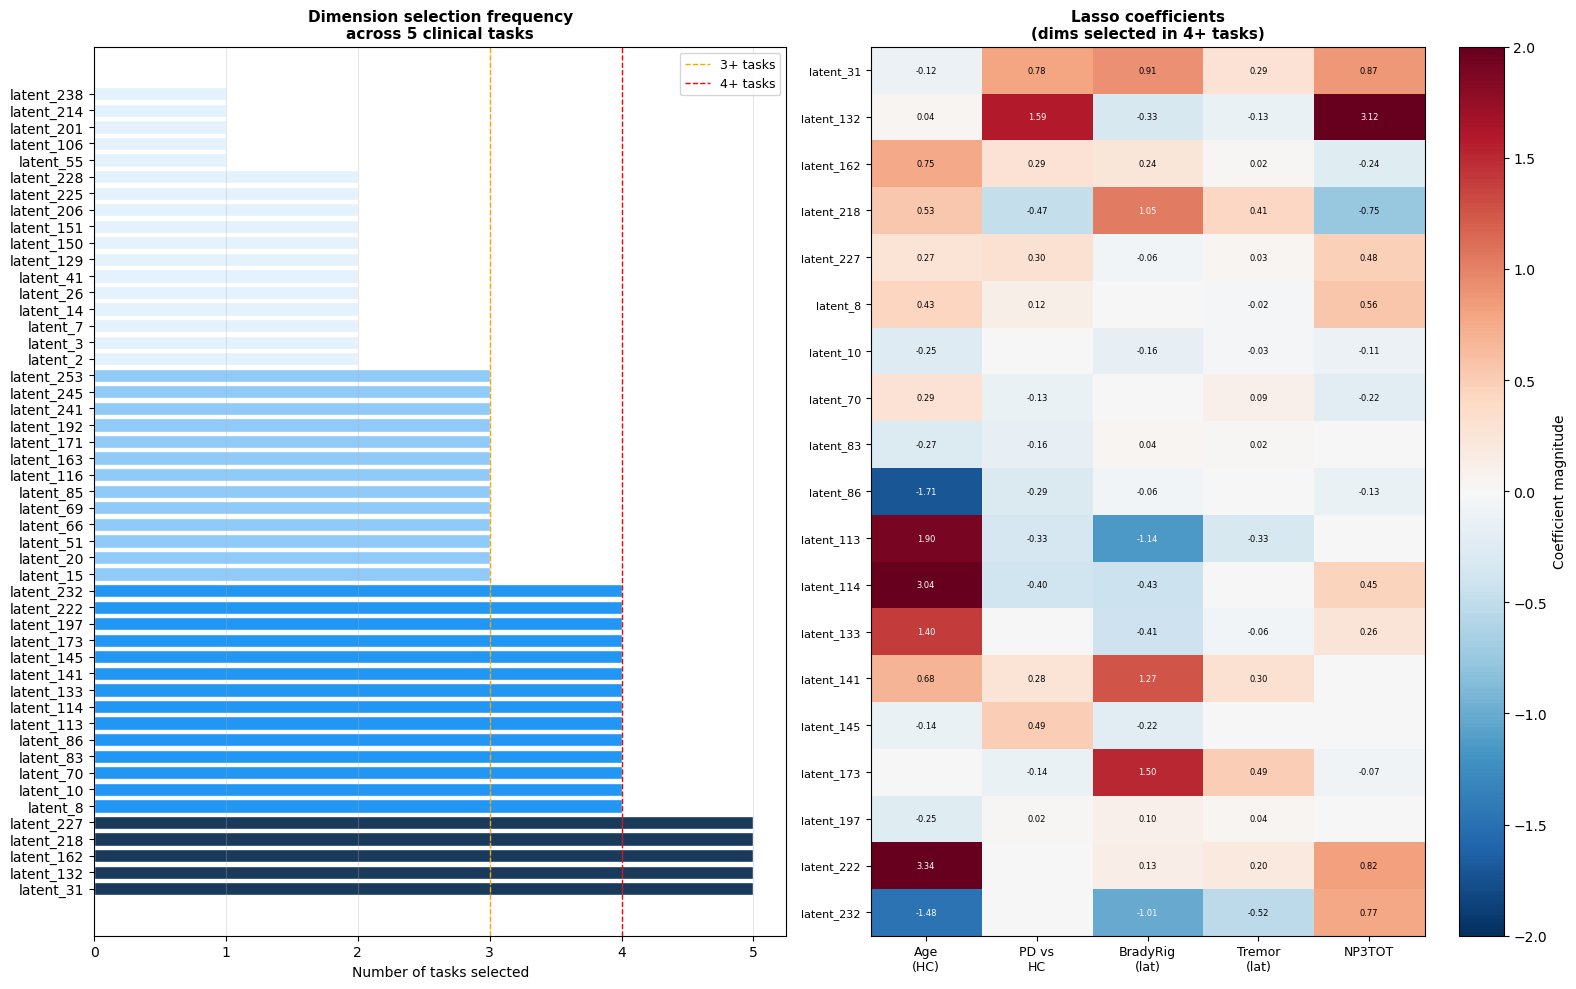

Saved: ../../results/figures/lasso_importance_beta_5e5.png


In [103]:
# [VISUALISATION]

fig, axes = plt.subplots(1, 2, figsize=(16, 10))

# ── Plot 1 — Task count per dimension ────────────────────────────
ax = axes[0]
dims_sorted = list(dim_task_count.keys())
counts      = [dim_task_count[d] for d in dims_sorted]
colors      = ['#1a3a5c' if c == 5 else
               '#2196F3' if c >= 4 else
               '#90CAF9' if c >= 3 else
               '#E3F2FD' for c in counts]

ax.barh(dims_sorted, counts, color=colors, edgecolor='white')
ax.axvline(3, color='orange', linestyle='--', linewidth=1, label='3+ tasks')
ax.axvline(4, color='red',    linestyle='--', linewidth=1, label='4+ tasks')
ax.set_xlabel('Number of tasks selected', fontsize=10)
ax.set_title('Dimension selection frequency\nacross 5 clinical tasks', fontsize=11, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(axis='x', alpha=0.3)

# ── Plot 2 — Coefficient heatmap ─────────────────────────────────
ax = axes[1]
task_names = list(results.keys())
dims_4plus = [d for d, c in dim_task_count.items() if c >= 4]

coef_matrix = np.zeros((len(dims_4plus), len(task_names)))
for j, task in enumerate(task_names):
    if results[task] is None:
        continue
    for i, dim in enumerate(dims_4plus):
        coef_matrix[i, j] = results[task]['coef'].get(dim, 0)

im = ax.imshow(coef_matrix, cmap='RdBu_r', aspect='auto',
               vmin=-2, vmax=2)
ax.set_xticks(range(len(task_names)))
ax.set_xticklabels(['Age\n(HC)', 'PD vs\nHC', 'BradyRig\n(lat)', 
                    'Tremor\n(lat)', 'NP3TOT'], fontsize=9)
ax.set_yticks(range(len(dims_4plus)))
ax.set_yticklabels(dims_4plus, fontsize=8)
ax.set_title('Lasso coefficients\n(dims selected in 4+ tasks)', 
             fontsize=11, fontweight='bold')
plt.colorbar(im, ax=ax, label='Coefficient magnitude')

# Add text values
for i in range(len(dims_4plus)):
    for j in range(len(task_names)):
        val = coef_matrix[i, j]
        if abs(val) > 0.01:
            ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                   fontsize=6, color='white' if abs(val) > 1 else 'black')

plt.tight_layout()
path = f'{FIGURES_DIR}lasso_importance_beta_5e5.png'
plt.savefig(path, dpi=150, bbox_inches='tight')
plt.show()
print(f"Saved: {path}")